In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

In [15]:
# ============================================
# CELL 1: Kaggle Setup & Imports
# ============================================

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4  # Using B4!
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Check if running on Kaggle
if os.path.exists('/kaggle/input'):
    print("✅ Running on Kaggle")
    ON_KAGGLE = True
else:
    print("⚠️ Not on Kaggle - adjust paths accordingly")
    ON_KAGGLE = False


TensorFlow: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ Running on Kaggle


In [16]:
# ============================================
# CELL 2: Configure Paths (KAGGLE VERSION)
# ============================================

if ON_KAGGLE:
    # Kaggle dataset paths
    # Add HAM10000 dataset from: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
    data_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
    
    # Kaggle has two folders
    image_dir1 = f'{data_dir}/HAM10000_images_part_1'
    image_dir2 = f'{data_dir}/HAM10000_images_part_2'
    metadata_path = f'{data_dir}/HAM10000_metadata.csv'
else:
    # Google Colab paths (fallback)
    data_dir = '/content/drive/MyDrive/skin_data_raw'
    image_dir1 = f'{data_dir}/ham10000_images_part_1'
    image_dir2 = f'{data_dir}/ham10000_images_part_2'
    metadata_path = f'{data_dir}/HAM10000_metadata.csv'

print(f"📂 Data directory: {data_dir}")

📂 Data directory: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000


In [17]:
# ============================================
# CELL 3: Load Metadata
# ============================================

metadata = pd.read_csv(metadata_path)
print(f"Total images: {len(metadata)}")
metadata.head()

Total images: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [18]:
# ============================================
# CELL 4: Add Image Paths
# ============================================

def get_path(image_id):
    """Find image in either part_1 or part_2 folder"""
    path1 = os.path.join(image_dir1, f'{image_id}.jpg')
    path2 = os.path.join(image_dir2, f'{image_id}.jpg')
    
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    return None

metadata['image_path'] = metadata['image_id'].apply(get_path)
metadata = metadata[metadata['image_path'].notna()].reset_index(drop=True)

print(f"✅ Valid images: {len(metadata)}")

# Verify a few paths
print("\n📂 Sample paths:")
for i in range(min(3, len(metadata))):
    print(f"  {metadata.iloc[i]['image_path']}")

✅ Valid images: 10015

📂 Sample paths:
  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027419.jpg
  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025030.jpg
  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026769.jpg


In [19]:
# ============================================
# CELL 5: Create Labels
# ============================================

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
metadata['label'] = metadata['dx'].map({name: i for i, name in enumerate(CLASS_NAMES)})

print("\n📊 Original class distribution:")
print(metadata['dx'].value_counts().sort_index())


📊 Original class distribution:
dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64


In [20]:
# ============================================
# CELL 6: Balance Dataset to 1000 per Class
# ============================================

print("\n🔄 Balancing dataset to 1000 images per class...")

TARGET_PER_CLASS = 1000
balanced_dfs = []

for class_name in CLASS_NAMES:
    class_df = metadata[metadata['dx'] == class_name].copy()
    current_count = len(class_df)
    
    print(f"\n{class_name}:")
    print(f"  Current: {current_count} images")
    
    if current_count >= TARGET_PER_CLASS:
        sampled_df = class_df.sample(n=TARGET_PER_CLASS, random_state=42)
        print(f"  Action: Downsampled to {TARGET_PER_CLASS}")
    else:
        n_to_generate = TARGET_PER_CLASS - current_count
        print(f"  Action: Using all {current_count} + generating {n_to_generate} augmented")
        
        sampled_df = class_df.copy()
        augmented_rows = []
        
        samples_generated = 0
        while samples_generated < n_to_generate:
            source_row = class_df.sample(n=1).iloc[0]
            augmented_row = source_row.copy()
            augmented_row['image_id'] = f"{source_row['image_id']}_aug{samples_generated}"
            augmented_rows.append(augmented_row)
            samples_generated += 1
        
        augmented_df = pd.DataFrame(augmented_rows)
        sampled_df = pd.concat([sampled_df, augmented_df], ignore_index=True)
    
    balanced_dfs.append(sampled_df)

balanced_metadata = pd.concat(balanced_dfs, ignore_index=True)

print("\n" + "="*60)
print("✅ BALANCED DATASET CREATED!")
print("="*60)
print(f"\n📊 New class distribution:")
print(balanced_metadata['dx'].value_counts().sort_index())
print(f"\nTotal images: {len(balanced_metadata)}")


🔄 Balancing dataset to 1000 images per class...

akiec:
  Current: 327 images
  Action: Using all 327 + generating 673 augmented

bcc:
  Current: 514 images
  Action: Using all 514 + generating 486 augmented

bkl:
  Current: 1099 images
  Action: Downsampled to 1000

df:
  Current: 115 images
  Action: Using all 115 + generating 885 augmented

mel:
  Current: 1113 images
  Action: Downsampled to 1000

nv:
  Current: 6705 images
  Action: Downsampled to 1000

vasc:
  Current: 142 images
  Action: Using all 142 + generating 858 augmented

✅ BALANCED DATASET CREATED!

📊 New class distribution:
dx
akiec    1000
bcc      1000
bkl      1000
df       1000
mel      1000
nv       1000
vasc     1000
Name: count, dtype: int64

Total images: 7000


In [21]:
# ============================================
# CELL 7: Train/Val/Test Split
# ============================================

print("\n🔀 Creating data splits...")

train_df, temp_df = train_test_split(
    balanced_metadata,
    test_size=0.3,
    stratify=balanced_metadata['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f"\n📊 Split sizes:")
print(f"  Training:   {len(train_df):5d} samples ({len(train_df)/len(balanced_metadata)*100:.1f}%)")
print(f"  Validation: {len(val_df):5d} samples ({len(val_df)/len(balanced_metadata)*100:.1f}%)")
print(f"  Test:       {len(test_df):5d} samples ({len(test_df)/len(balanced_metadata)*100:.1f}%)")



🔀 Creating data splits...

📊 Split sizes:
  Training:    4900 samples (70.0%)
  Validation:  1050 samples (15.0%)
  Test:        1050 samples (15.0%)


In [22]:
# ============================================
# CELL 8: Data Generators - OPTIMIZED FOR B4
# ============================================

IMG_SIZE = 300  # ✅ Standard size (B4 can handle larger but 224 prevents overfitting)
BATCH_SIZE = 16  # ✅ Smaller for B4 (larger model, more memory)

print(f"\n🔧 Configuration (Optimized for EfficientNetB4):")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE} (smaller for B4)")
print(f"  Dataset: {len(balanced_metadata)} images")

# Strong augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = val_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print(f"\n✅ Data generators created:")
print(f"  Train: {train_generator.samples} samples, {len(train_generator)} batches")
print(f"  Val:   {val_generator.samples} samples, {len(val_generator)} batches")
print(f"  Test:  {test_generator.samples} samples, {len(test_generator)} batches")



🔧 Configuration (Optimized for EfficientNetB4):
  Image Size: 300x300
  Batch Size: 16 (smaller for B4)
  Dataset: 7000 images
Found 4900 validated image filenames belonging to 7 classes.
Found 1050 validated image filenames belonging to 7 classes.
Found 1050 validated image filenames belonging to 7 classes.

✅ Data generators created:
  Train: 4900 samples, 307 batches
  Val:   1050 samples, 66 batches
  Test:  1050 samples, 66 batches


In [23]:
# ============================================
# CELL 9: Build EfficientNetB4 Model
# ============================================

print("\n🏗️ Building EfficientNetB4 model...")
print("⚠️ Note: B4 is larger than B3 - better accuracy but slower")

try:
    # Try to load with internet
    base_model = EfficientNetB4(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    print("✅ Loaded ImageNet weights online")
except Exception as e:
    print(f"⚠️ Could not download weights online: {e}")
    print("🔄 Trying to load from Kaggle cache...")
    
    try:
        # Kaggle caches weights locally
        base_model = EfficientNetB4(
            weights='imagenet',
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        print("✅ Loaded from Kaggle cache")
    except Exception as e2:
        print(f"❌ Cache failed: {e2}")
        print("💡 Solution: Training from scratch (no ImageNet weights)")
        base_model = EfficientNetB4(
            weights=None,  # No pre-trained weights
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        print("⚠️ Training from scratch - will take longer and need more epochs")

# Freeze base
base_model.trainable = False

# Build top layers with L2 regularization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(512, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

outputs = Dense(7, activation='softmax')(x)

model = Model(base_model.input, outputs)

print("✅ EfficientNetB4 model built!")



🏗️ Building EfficientNetB4 model...
⚠️ Note: B4 is larger than B3 - better accuracy but slower
✅ Loaded ImageNet weights online
✅ EfficientNetB4 model built!


In [24]:
# ============================================
# CELL 10: Compile Model
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("✅ Model compiled!")

# Show model info
# ✅ NEW (works):
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
total_params = np.sum([np.prod(v.shape) for v in model.weights])
print(f"\n📊 Model Parameters:")
print(f"  Trainable: {trainable_params:,}")
print(f"  Total:     {total_params:,}")
print(f"  B4 vs B3: ~60% more parameters (better accuracy)")


✅ Model compiled!

📊 Model Parameters:
  Trainable: 1,056,263
  Total:     18,735,206.0
  B4 vs B3: ~60% more parameters (better accuracy)


In [25]:
# ============================================
# CELL 11: Setup Callbacks
# ============================================

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    
    ModelCheckpoint(
        'efficientnetb4_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("✅ Callbacks configured!")


✅ Callbacks configured!


In [26]:
# ============================================
# CELL 12: Phase 1 Training - Frozen Base
# ============================================

print("\n" + "="*60)
print("🚀 PHASE 1: Training with frozen base")
print("="*60)
print(f"Epochs: 40")
print(f"Learning Rate: 0.001")
print(f"Batch Size: {BATCH_SIZE}")
print("="*60)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Phase 1 complete!")

best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"\n📊 Best Phase 1 Results:")
print(f"  Best Epoch: {best_epoch}")
print(f"  Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")



🚀 PHASE 1: Training with frozen base
Epochs: 40
Learning Rate: 0.001
Batch Size: 16


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
283/307 ━━━━━━━━━━━━━━━━━━━━ 11s 461ms/step - accuracy: 0.2988 - auc: 0.6876 - loss: 3.4688

2026-03-03 05:52:46.786446: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 05:52:46.921076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 05:52:47.146558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 05:52:47.281132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 05:52:47.511688: E external/local_xla/xla/stream_

307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.3028 - auc: 0.6917 - loss: 3.4483

...

307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 428ms/step - accuracy: 0.4857 - auc: 0.8392 - loss: 2.6640 - val_accuracy: 0.5895 - val_auc: 0.8987 - val_loss: 2.3208 - learning_rate: 0.0010
Epoch 4/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5123 - auc: 0.8572 - loss: 2.5102
Epoch 4: val_accuracy did not improve from 0.58952
307/307 ━━━━━━━━━━━━━━━━━━━━ 129s 421ms/step - accuracy: 0.5123 - auc: 0.8572 - loss: 2.5101 - val_accuracy: 0.5895 - val_auc: 0.8976 - val_loss: 2.2565 - learning_rate: 0.0010
Epoch 5/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5208 - auc: 0.8616 - loss: 2.4170
Epoch 5: val_accuracy did not improve from 0.58952
307/307 ━━━━━━━━━━━━━━━━━━━━ 131s 427ms/step - accuracy: 0.5208 - auc: 0.8616 - loss: 2.4169 - val_accuracy: 0.5714 - val_auc: 0.8965 - val_loss: 2.1864 - learning_rate: 0.0010
Epoch 6/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5261 - auc: 0.8653 - loss: 2.3292
Epoch 6: val_accuracy improved from 0.58952 to 0.64667, savin

307/307 ━━━━━━━━━━━━━━━━━━━━ 131s 427ms/step - accuracy: 0.5261 - auc: 0.8653 - loss: 2.3291 - val_accuracy: 0.6467 - val_auc: 0.9169 - val_loss: 2.0210 - learning_rate: 0.0010
Epoch 7/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.5284 - auc: 0.8734 - loss: 2.2115
Epoch 7: val_accuracy did not improve from 0.64667
307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 424ms/step - accuracy: 0.5284 - auc: 0.8734 - loss: 2.2114 - val_accuracy: 0.5714 - val_auc: 0.8976 - val_loss: 2.0334 - learning_rate: 0.0010
Epoch 8/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5315 - auc: 0.8732 - loss: 2.1486
Epoch 8: val_accuracy did not improve from 0.64667
307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 425ms/step - accuracy: 0.5315 - auc: 0.8732 - loss: 2.1485 - val_accuracy: 0.5838 - val_auc: 0.8915 - val_loss: 2.0120 - learning_rate: 0.0010
Epoch 9/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5523 - auc: 0.8752 - loss: 2.0818
Epoch 9: val_accuracy did not improve from 0.64667
307/307 ━━

307/307 ━━━━━━━━━━━━━━━━━━━━ 131s 426ms/step - accuracy: 0.5923 - auc: 0.9010 - loss: 1.6397 - val_accuracy: 0.6619 - val_auc: 0.9277 - val_loss: 1.4936 - learning_rate: 5.0000e-04
Epoch 19/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5802 - auc: 0.8973 - loss: 1.6440
Epoch 19: val_accuracy did not improve from 0.66190
307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 424ms/step - accuracy: 0.5802 - auc: 0.8973 - loss: 1.6439 - val_accuracy: 0.6314 - val_auc: 0.9205 - val_loss: 1.5131 - learning_rate: 5.0000e-04
Epoch 20/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5971 - auc: 0.9064 - loss: 1.5872
Epoch 20: val_accuracy did not improve from 0.66190
307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 424ms/step - accuracy: 0.5970 - auc: 0.9063 - loss: 1.5873 - val_accuracy: 0.6429 - val_auc: 0.9241 - val_loss: 1.4798 - learning_rate: 5.0000e-04
Epoch 21/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.5810 - auc: 0.8973 - loss: 1.6250
Epoch 21: val_accuracy did not improve from 

307/307 ━━━━━━━━━━━━━━━━━━━━ 131s 425ms/step - accuracy: 0.5795 - auc: 0.9014 - loss: 1.5815 - val_accuracy: 0.6695 - val_auc: 0.9282 - val_loss: 1.4412 - learning_rate: 5.0000e-04
Epoch 25/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5789 - auc: 0.9019 - loss: 1.5739
Epoch 25: val_accuracy did not improve from 0.66952
307/307 ━━━━━━━━━━━━━━━━━━━━ 131s 426ms/step - accuracy: 0.5788 - auc: 0.9019 - loss: 1.5740 - val_accuracy: 0.6324 - val_auc: 0.9148 - val_loss: 1.4967 - learning_rate: 5.0000e-04
Epoch 26/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.5914 - auc: 0.9022 - loss: 1.5709
Epoch 26: val_accuracy did not improve from 0.66952
307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 423ms/step - accuracy: 0.5914 - auc: 0.9022 - loss: 1.5709 - val_accuracy: 0.6571 - val_auc: 0.9283 - val_loss: 1.4195 - learning_rate: 5.0000e-04
Epoch 27/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.5881 - auc: 0.9007 - loss: 1.5781
Epoch 27: val_accuracy did not improve from 

307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 424ms/step - accuracy: 0.5834 - auc: 0.8993 - loss: 1.5774 - val_accuracy: 0.6771 - val_auc: 0.9344 - val_loss: 1.3970 - learning_rate: 5.0000e-04
Epoch 32/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5911 - auc: 0.9014 - loss: 1.5636
Epoch 32: val_accuracy did not improve from 0.67714
307/307 ━━━━━━━━━━━━━━━━━━━━ 131s 427ms/step - accuracy: 0.5911 - auc: 0.9014 - loss: 1.5636 - val_accuracy: 0.6724 - val_auc: 0.9302 - val_loss: 1.3989 - learning_rate: 5.0000e-04
Epoch 33/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5937 - auc: 0.9037 - loss: 1.5482
Epoch 33: val_accuracy did not improve from 0.67714
307/307 ━━━━━━━━━━━━━━━━━━━━ 129s 420ms/step - accuracy: 0.5937 - auc: 0.9037 - loss: 1.5483 - val_accuracy: 0.6410 - val_auc: 0.9191 - val_loss: 1.4594 - learning_rate: 5.0000e-04
Epoch 34/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5971 - auc: 0.9030 - loss: 1.5517
Epoch 34: val_accuracy did not improve from 

In [27]:
# ============================================
# CELL 13: Phase 2 Fine-Tuning - PROPER LR!
# ============================================

print("\n" + "="*60)
print("🚀 PHASE 2: Fine-tuning with unfrozen layers")
print("="*60)

# Unfreeze last 50 layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

trainable_layers = sum([layer.trainable for layer in base_model.layers])
print(f"Trainable B4 layers: {trainable_layers}")

# ✅ CRITICAL: Recompile with LOWER learning rate!
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),  # 20x lower!
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f"Learning Rate: 5e-5 (20x lower)")
print(f"Epochs: 40")
print("="*60)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Phase 2 complete!")

best_val_acc_fine = max(history_fine.history['val_accuracy'])
best_epoch_fine = history_fine.history['val_accuracy'].index(best_val_acc_fine) + 1
print(f"\n📊 Best Phase 2 Results:")
print(f"  Best Epoch: {best_epoch_fine}")
print(f"  Val Accuracy: {best_val_acc_fine:.4f} ({best_val_acc_fine*100:.2f}%)")



🚀 PHASE 2: Fine-tuning with unfrozen layers
Trainable B4 layers: 50
Learning Rate: 5e-5 (20x lower)
Epochs: 40
Epoch 1/40


2026-03-03 07:08:24.983696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:08:25.135845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:08:25.381141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:08:25.533287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:08:25.954367: E external/local_xla/xla/stream_

 90/307 ━━━━━━━━━━━━━━━━━━━━ 1:26 400ms/step - accuracy: 0.5394 - auc: 0.8717 - loss: 1.7213

2026-03-03 07:09:30.372502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:09:30.525447: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:09:30.768404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:09:30.919762: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 07:09:31.224805: E external/local_xla/xla/stream_

307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.5562 - auc: 0.8832 - loss: 1.6617
Epoch 1: val_accuracy did not improve from 0.67714
307/307 ━━━━━━━━━━━━━━━━━━━━ 235s 589ms/step - accuracy: 0.5563 - auc: 0.8833 - loss: 1.6615 - val_accuracy: 0.6438 - val_auc: 0.9286 - val_loss: 1.3988 - learning_rate: 5.0000e-05
Epoch 2/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6357 - auc: 0.9182 - loss: 1.4634
Epoch 2: val_accuracy improved from 0.67714 to 0.69714, saving model to efficientnetb4_best.h5


...

307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 429ms/step - accuracy: 0.8584 - auc: 0.9865 - loss: 0.6793 - val_accuracy: 0.8371 - val_auc: 0.9792 - val_loss: 0.7538 - learning_rate: 5.0000e-05
Epoch 28/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8650 - auc: 0.9865 - loss: 0.6700
Epoch 28: val_accuracy did not improve from 0.83714
307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 430ms/step - accuracy: 0.8650 - auc: 0.9865 - loss: 0.6700 - val_accuracy: 0.8219 - val_auc: 0.9742 - val_loss: 0.8092 - learning_rate: 5.0000e-05
Epoch 29/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8597 - auc: 0.9876 - loss: 0.6493
Epoch 29: val_accuracy improved from 0.83714 to 0.83810, saving model to efficientnetb4_best.h5


307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 430ms/step - accuracy: 0.8597 - auc: 0.9876 - loss: 0.6493 - val_accuracy: 0.8381 - val_auc: 0.9775 - val_loss: 0.7609 - learning_rate: 5.0000e-05
Epoch 30/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8632 - auc: 0.9884 - loss: 0.6324
Epoch 30: val_accuracy did not improve from 0.83810
307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 429ms/step - accuracy: 0.8632 - auc: 0.9884 - loss: 0.6325 - val_accuracy: 0.8381 - val_auc: 0.9779 - val_loss: 0.7498 - learning_rate: 5.0000e-05
Epoch 31/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8531 - auc: 0.9858 - loss: 0.6545
Epoch 31: val_accuracy did not improve from 0.83810
307/307 ━━━━━━━━━━━━━━━━━━━━ 130s 424ms/step - accuracy: 0.8531 - auc: 0.9858 - loss: 0.6545 - val_accuracy: 0.8276 - val_auc: 0.9760 - val_loss: 0.7771 - learning_rate: 5.0000e-05
Epoch 32/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8729 - auc: 0.9884 - loss: 0.6112
Epoch 32: val_accuracy did not improve from 

307/307 ━━━━━━━━━━━━━━━━━━━━ 133s 431ms/step - accuracy: 0.8849 - auc: 0.9909 - loss: 0.5541 - val_accuracy: 0.8390 - val_auc: 0.9773 - val_loss: 0.7179 - learning_rate: 2.5000e-05
Epoch 38/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8804 - auc: 0.9904 - loss: 0.5611
Epoch 38: val_accuracy improved from 0.83905 to 0.84190, saving model to efficientnetb4_best.h5


307/307 ━━━━━━━━━━━━━━━━━━━━ 134s 435ms/step - accuracy: 0.8804 - auc: 0.9904 - loss: 0.5611 - val_accuracy: 0.8419 - val_auc: 0.9800 - val_loss: 0.6936 - learning_rate: 2.5000e-05
Epoch 39/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8896 - auc: 0.9918 - loss: 0.5322
Epoch 39: val_accuracy improved from 0.84190 to 0.84762, saving model to efficientnetb4_best.h5


307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 429ms/step - accuracy: 0.8896 - auc: 0.9918 - loss: 0.5322 - val_accuracy: 0.8476 - val_auc: 0.9790 - val_loss: 0.7006 - learning_rate: 2.5000e-05
Epoch 40/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8908 - auc: 0.9908 - loss: 0.5448
Epoch 40: val_accuracy did not improve from 0.84762
307/307 ━━━━━━━━━━━━━━━━━━━━ 133s 432ms/step - accuracy: 0.8908 - auc: 0.9908 - loss: 0.5448 - val_accuracy: 0.8467 - val_auc: 0.9787 - val_loss: 0.6944 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 39.

✅ Phase 2 complete!

📊 Best Phase 2 Results:
  Best Epoch: 39
  Val Accuracy: 0.8476 (84.76%)


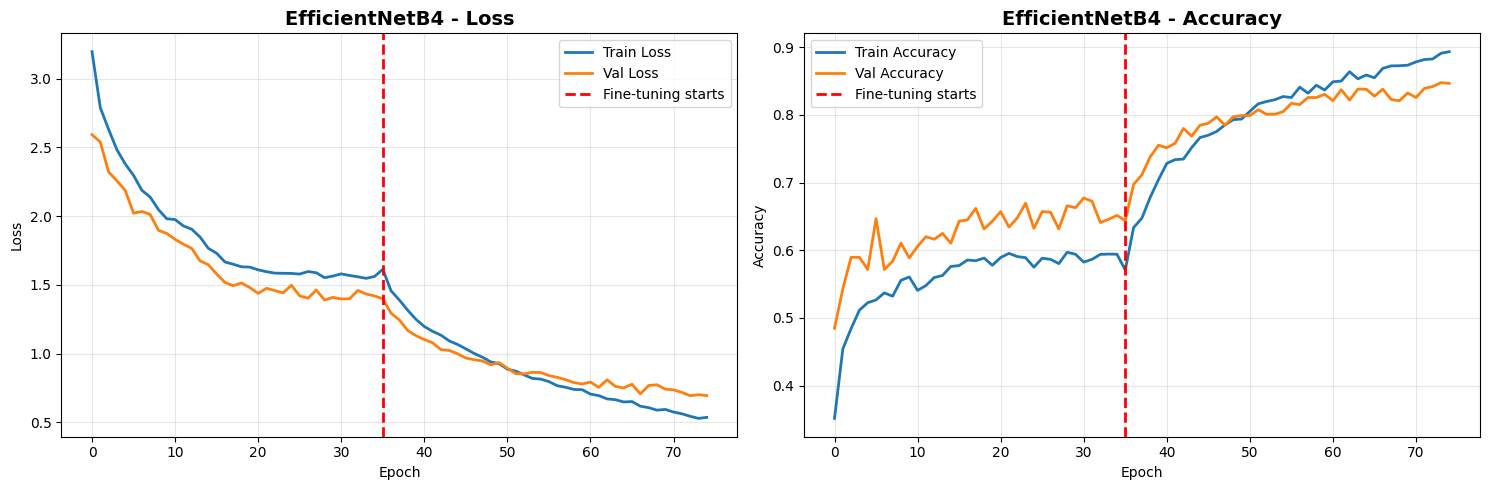


📊 Final Training Results:
  Training Accuracy:   0.8935 (89.35%)
  Validation Accuracy: 0.8467 (84.67%)
  Overfitting Gap:     0.0468 (4.68%)
  ✅ Good! Acceptable overfitting


In [28]:
# ============================================
# CELL 14: Plot Results
# ============================================

import matplotlib.pyplot as plt

history_combined = {
    'loss': history.history['loss'] + history_fine.history['loss'],
    'val_loss': history.history['val_loss'] + history_fine.history['val_loss'],
    'accuracy': history.history['accuracy'] + history_fine.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'] + history_fine.history['val_accuracy']
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history_combined['loss'], label='Train Loss', linewidth=2)
ax1.plot(history_combined['val_loss'], label='Val Loss', linewidth=2)
ax1.axvline(x=len(history.history['loss']), color='red', 
            linestyle='--', linewidth=2, label='Fine-tuning starts')
ax1.set_title('EfficientNetB4 - Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history_combined['accuracy'], label='Train Accuracy', linewidth=2)
ax2.plot(history_combined['val_accuracy'], label='Val Accuracy', linewidth=2)
ax2.axvline(x=len(history.history['loss']), color='red', 
            linestyle='--', linewidth=2, label='Fine-tuning starts')
ax2.set_title('EfficientNetB4 - Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final metrics
final_train_acc = history_combined['accuracy'][-1]
final_val_acc = history_combined['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f"\n📊 Final Training Results:")
print(f"  Training Accuracy:   {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Overfitting Gap:     {gap:.4f} ({gap*100:.2f}%)")

if gap < 0.03:
    print(f"  ✅ Excellent! Minimal overfitting")
elif gap < 0.05:
    print(f"  ✅ Good! Acceptable overfitting")
else:
    print(f"  ⚠️ Some overfitting present")



In [29]:
# ============================================
# CELL 15: Evaluate on Test Set
# ============================================

print("\n" + "="*60)
print("📊 FINAL EVALUATION ON TEST SET")
print("="*60)

test_results = model.evaluate(test_generator, verbose=1)

print(f"\n✅ Test Results:")
print(f"  Test Loss:     {test_results[0]:.4f}")
print(f"  Test Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")
print(f"  Test AUC:      {test_results[2]:.4f}")

# Predictions
print("\n🔮 Generating predictions...")
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\n📋 Classification Report:")
print("="*60)
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES, digits=4))



📊 FINAL EVALUATION ON TEST SET
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.8456 - auc: 0.9839 - loss: 0.6469

✅ Test Results:
  Test Loss:     0.6780
  Test Accuracy: 0.8448 (84.48%)
  Test AUC:      0.9813

🔮 Generating predictions...
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 281ms/step

📋 Classification Report:
              precision    recall  f1-score   support

       akiec     0.9845    0.8467    0.9104       150
         bcc     0.9343    0.8533    0.8920       150
         bkl     0.6444    0.7733    0.7030       150
          df     0.9363    0.9800    0.9577       150
         mel     0.6768    0.7400    0.7070       150
          nv     0.8372    0.7200    0.7742       150
        vasc     0.9740    1.0000    0.9868       150

    accuracy                         0.8448      1050
   macro avg     0.8554    0.8448    0.8473      1050
weighted avg     0.8554    0.8448    0.8473      1050



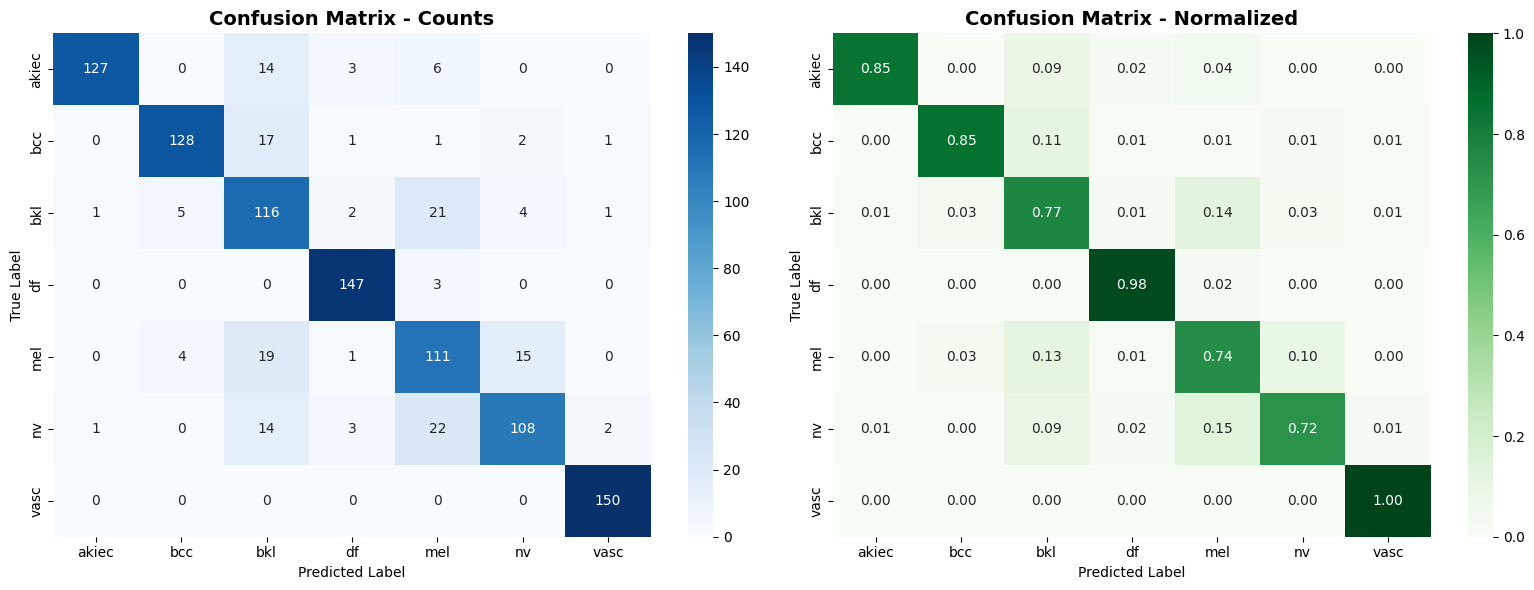

In [30]:
# ============================================
# CELL 16: Confusion Matrix
# ============================================

cm = confusion_matrix(y_true, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title('Confusion Matrix - Counts', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
ax2.set_title('Confusion Matrix - Normalized', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

